<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Monte_Carlo_Integration_Simulation_with_CuPy_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# GPU-Accelerated Hit-or-Miss Monte Carlo Integration of $\sin(x)$

## 1. Motivation

Deterministic quadrature typically handles numerical integration. Monte Carlo methods offer an alternative by treating integrals as statistical expectations derived from random samples. Such techniques excel in high-dimensional spaces or stochastic models [1–3]. This notebook employs a simple one-dimensional case to permit continuous comparison against an analytic solution.

A bounded geometric region with an exact area of $2$ results from applying $f(x)=\sin(x)$ on $0\leq x\leq\pi$. Random points drawn from the rectangle $[0,\pi]\times[0,1]$ are classified according to their position relative to the curve. The fraction falling below $\sin(x)$ estimates the proportion of the rectangle occupied by the target region, mapping geometric sampling to numerical integration.

Random number generation, sine evaluation, and Boolean point classification occur on the GPU via CuPy. Array-based stochastic workloads expose independent calculations that map efficiently onto GPU hardware at larger problem sizes [4,5]. Visualization and GIF construction shift to the CPU, where Matplotlib and Pillow produce a cumulative animation in which the estimate evolves as progressively larger prefixes of one Monte Carlo realization are revealed.

This notebook serves dual purposes. It demonstrates the mathematical structure of hit-or-miss Monte Carlo integration and illustrates the division of a stochastic numerical workload between GPU computation and CPU visualization.

## 2. Comprehensive Notation Table

| Symbol or code quantity | Definition | Value in this notebook | Units or type |
| :--- | :--- | :---: | :---: |
| $x$ | Independent variable of the integrand | $0\leq x\leq\pi$ | Dimensionless |
| $y$ | Vertical coordinate of a sampled point | $0\leq y\leq1$ | Dimensionless |
| $f(x)$ | Function being integrated | $\sin(x)$ | Dimensionless |
| $a$ | Lower integration boundary, `X_MIN` | $0$ | Dimensionless |
| $b$ | Upper integration boundary, `X_MAX` | $\pi$ | Dimensionless |
| $c$ | Lower sampling boundary, `Y_MIN` | $0$ | Dimensionless |
| $d$ | Upper sampling boundary, `Y_MAX` | $1$ | Dimensionless |
| $B$ | Rectangular Monte Carlo sampling domain | $[a,b]\times[c,d]$ | Dimensionless area |
| $A_B$ | Area of the bounding rectangle | $\pi$ | Dimensionless area |
| $I$ | Exact value of the target integral | $2$ | Dimensionless area |
| $(X_i,Y_i)$ | Coordinates of Monte Carlo sample $i$ | Uniformly distributed in $B$ | Random pair |
| $H_i$ | Hit indicator for sample $i$ | $0$ or $1$ | Boolean |
| $p$ | True probability that a random point is a hit | $2/\pi$ | Probability |
| $\widehat{p}_N$ | Observed hit fraction after $N$ samples | Run dependent | Probability |
| $\widehat{I}_N$ | Hit-or-miss Monte Carlo estimate of $I$ | Run dependent | Dimensionless area |
| $\widetilde{I}_N$ | Direct function averaging Monte Carlo estimator | Run dependent | Dimensionless area |
| $\varepsilon_N$ | Realized absolute integration error | $\lvert\widehat{I}_N-I\rvert$ | Dimensionless area |
| $\sigma_{\widehat{I}_N}$ | Standard deviation of the hit-or-miss estimator | $N$ dependent | Dimensionless area |
| $N$ | Total number of generated samples, `TOTAL_POINTS` | $10{,}000$ | Samples |
| $F$ | Number of animation frames, `FRAMES` | $50$ | Frames |
| $M$ | Newly revealed samples per frame | $N/F=200$ | Samples per frame |
| $N_k$ | Cumulative number of visible samples at frame $k$ | $kM$ | Samples |
| $\nu_{\mathrm{GIF}}$ | GIF playback rate, `GIF_FPS` | $12$ | Frames $\mathrm{s}^{-1}$ |
| $q$ | CuPy memory pool clearing interval, `FREE_MEMORY_INTERVAL` | $8$ | Frames |
| $D$ | Matplotlib rendering density, `DPI` | $250$ | Dots per inch |
| $z_{0.975}$ | Standard normal coefficient for $95\%$ interval | $1.96$ | Dimensionless |

## 3. First Principles and Fundamental Theory

### 3.1 Integral as a geometric area

A nonnegative function $f(x)$ over an interval $[a,b]$ defines a definite integral representing the area bounded by the curve and the horizontal axis:

$$
I=\int_a^b f(x)\,dx
$$

The present notebook selects:

$$
f(x)=\sin(x),\qquad a=0,\qquad b=\pi
$$

Direct integration supplies an analytic reference for comparison:

$$
I=\int_0^\pi \sin(x)\,dx=\left[-\cos(x)\right]_0^\pi=2
$$

Selecting $0\leq y\leq1$ encloses the complete positive lobe of $\sin(x)$ inside a rectangle. The area of this rectangle is:

$$
A_B=(b-a)(d-c)=\pi
$$

The target region occupies a fraction $2/\pi$ of the enclosing rectangle.

### 3.2 Random sampling and the hit indicator

Monte Carlo integration replaces deterministic quadrature nodes with random sampling [1–3]. Each sample in this notebook obeys:

$$
(X_i,Y_i)\sim\mathcal{U}(B)
$$

Here $\mathcal{U}(B)$ denotes the uniform distribution over the rectangular domain $B$. A point is classified as a hit if its vertical coordinate lies below the sine curve. The indicator variable:

$$
H_i=\mathbf{1}\left(Y_i\leq\sin(X_i)\right)
$$

converts this geometric condition into a Bernoulli random variable. The symbol $\mathbf{1}(\cdot)$ equals $1$ for a true condition and $0$ otherwise. Uniform sampling ensures the probability of a hit equals the ratio of the desired area to the total bounding area:

$$
p=\Pr(H_i=1)=\frac{I}{A_B}
$$

For this geometry:

$$
p=\frac{2}{\pi}\approx0.63661977
$$

The observed fraction of hits after $N$ samples is:

$$
\widehat{p}_N=\frac{1}{N}\sum_{i=1}^{N}H_i
$$

Multiplying this fraction by the rectangular area yields the Monte Carlo integration estimator:

$$
\widehat{I}_N=A_B\widehat{p}_N=\frac{A_B}{N}\sum_{i=1}^{N}H_i
$$

The expectation of this estimator equals the desired integral:

$$
\mathbb{E}\left[\widehat{I}_N\right]=A_Bp=I
$$

This estimator is unbiased given uniform independent sampling and a correctly configured bounding rectangle.

### 3.3 Statistical variance and convergence

Each $H_i$ follows a Bernoulli distribution with variance:

$$
\operatorname{Var}(H_i)=p(1-p)
$$

Independence among the samples defines the area estimator variance:

$$
\operatorname{Var}\left(\widehat{I}_N\right)=\frac{A_B^2p(1-p)}{N}
$$

The standard deviation, or Monte Carlo standard error, is:

$$
\sigma_{\widehat{I}_N}=A_B\sqrt{\frac{p(1-p)}{N}}
$$

The characteristic stochastic error follows the scaling law:

$$
\sigma_{\widehat{I}_N}\propto N^{-1/2}
$$

This inverse square root convergence is central to ordinary Monte Carlo integration [2,3]. Halving the statistical error requires approximately four times as many independent samples.

For sufficiently large $N$, the central limit approximation provides an approximate $95\%$ interval:

$$
\widehat{I}_N\pm z_{0.975}\sigma_{\widehat{I}_N}
$$

The value $z_{0.975}\approx1.96$ characterizes sampling uncertainty across repeated realizations. The animation instead displays the realized absolute error for the specific random sequence being shown:

$$
\varepsilon_N=\left|\widehat{I}_N-I\right|
$$

## 4. Operational Scaling and Implementation

### 4.1 GPU generation of the Monte Carlo realization

Pre-calculation of the full set of $N=10{,}000$ random points occurs before animation begins. CuPy allocates `x_gpu` and `y_gpu` on the GPU and fills them using uniform pseudorandom samples:

```text
x_gpu = cp.random.uniform(X_MIN, X_MAX, TOTAL_POINTS)
y_gpu = cp.random.uniform(Y_MIN, Y_MAX, TOTAL_POINTS)
```

The GPU then evaluates all sine values in an array operation:

```text
y_curve_gpu = cp.sin(x_gpu)
```

Hit classification is performed element by element:

```text
hits_gpu = y_gpu <= y_curve_gpu
```

These operations are naturally data parallel. Each sampled point is generated and classified independently, allowing larger workloads to exploit the execution units available on modern GPUs [4,5]. GPU acceleration here applies to sample generation and function evaluation. The workload of $10{,}000$ samples serves as a demonstration of GPU structured computation. Larger $N$ or more expensive integrands provide a stronger computational motivation for this approach.

### 4.2 CPU construction of the reference curve

A smooth line for visualization is generated separately with NumPy:

$$
x_j=a+j\frac{b-a}{499},\qquad j=0,\ldots,499
$$

Evaluating $\sin(x_j)$ on these $500$ coordinates creates the blue reference curve drawn by Matplotlib. This line remains separate from the Monte Carlo estimate, which relies on CuPy arrays.

### 4.3 Progressive prefix sampling

The total sample population is divided across $F$ frames according to:

$$
M=\left\lfloor\frac{N}{F}\right\rfloor
$$

With the supplied parameters, $M=200$. Frame $k$ displays the first:

$$
N_k=kM
$$

samples from the original realization. The animation exposes one cumulative trajectory of the estimator instead of producing fresh independent experiments at every frame.

For example, the first several frames contain $N_1=200$, $N_2=400$, and $N_3=600$. The final frame reaches $N_{50}=10{,}000$. Nested prefixes make neighboring frames correlated. Every point in frame $k$ also appears in frame $k+1$. This design provides a direct visualization of convergence along a single stochastic sample path.

### 4.4 GPU to CPU transfer

Current prefixes of the GPU arrays are copied to host memory at every animation step using `cp.asnumpy()`:

```text
x_cpu = cp.asnumpy(x_gpu[:current_index])
y_cpu = cp.asnumpy(y_gpu[:current_index])
hits_cpu = cp.asnumpy(hits_gpu[:current_index])
```

The reduction `hits_count = np.sum(hits_cpu)` occurs on the CPU. From that count, the code evaluates:

$$
\widehat{I}_{N_k}=A_B\frac{N_{\mathrm{hit},k}}{N_k}
$$

Repeated prefix transfer means earlier points cross the GPU-to-CPU boundary multiple times. Total transferred entries are proportional to:

$$
\sum_{k=1}^{F}N_k=\frac{N(F+1)}{2}
$$

For $N=10{,}000$ and $F=50$, this sum equals $255{,}000$. The calculation scales linearly with the number of samples, whereas cumulative visualization adds repeated data movement. Host-device transfer is often a significant component of GPU program timing for workloads with modest arithmetic intensity [4].

### 4.5 In-memory image construction

`fig.savefig()` writes a PNG image into an `io.BytesIO` buffer after each scatter plot is rendered. Pillow opens that buffer and stores the resulting image object in `image_frames`. No intermediate PNG file is required on persistent storage.

Pillow combines these $F$ images into another in-memory byte stream. The nominal duration of each frame is:

$$
\Delta t_{\mathrm{frame}}=\frac{1}{\nu_{\mathrm{GIF}}}
$$

At $\nu_{\mathrm{GIF}}=12~\mathrm{frames,s^{-1}}$, $\Delta t_{\mathrm{frame}}\approx83.3~\mathrm{ms}$. One complete playback cycle lasts:

$$
T_{\mathrm{GIF}}=\frac{F}{\nu_{\mathrm{GIF}}}\approx4.17~\mathrm{s}
$$

The completed byte stream is passed directly to IPython for display.

## 5. Advanced Phenomena and Numerical Nuances

### 5.1 Realized error vs statistical uncertainty

The animation reports:

$$
\varepsilon_{N_k}=\left|\widehat{I}_{N_k}-2\right|
$$

This value can rise temporarily as additional samples are accumulated. Monte Carlo convergence describes statistical scaling across repeated realizations; it does not require every successive estimate to move monotonically closer to the exact value. A sequence might show an excellent estimate at an early frame followed by a larger error several frames later. The characteristic width of the estimator distribution contracts according to $N^{-1/2}$ over sufficiently many samples.

### 5.2 Validity of the bounding rectangle

The estimator assumes the target curve lies between the vertical sampling limits:

$$
c\leq f(x)\leq d
$$

over the entire interval $a\leq x\leq b$. For a general lower bound $c$, the area represented by the hit probability equals the region from $y=c$ to $y=f(x)$. The integral relation is:

$$
I=c(b-a)+A_Bp
$$

A generalized estimator takes the form:

$$
\widehat{I}_N=c(b-a)+A_B\widehat{p}_N
$$

The implemented code uses $A_B\widehat{p}_N$, which is correct for $c=0$. Changing `Y_MIN` away from zero requires including the baseline contribution $c(b-a)$. Similarly, `Y_MAX` must enclose the maximum function value.

### 5.3 Integration interval adjustments

The hard-coded value `exact_area = 2.0` corresponds specifically to $a=0$ and $b=\pi$. For arbitrary horizontal boundaries, the analytic integral is:

$$
I(a,b)=\cos(a)-\cos(b)
$$

Updating `X_MIN` or `X_MAX` requires a corresponding update to the analytic reference. Intervals containing negative values of $\sin(x)$ require a signed integration treatment or a vertically shifted sampling rectangle.

### 5.4 Frame correlation

Only one pair of random GPU arrays is generated. The animation slices increasingly long prefixes:

$$
\{1,\ldots,N_k\}\subset\{1,\ldots,N_{k+1}\}
$$

Successive estimates share most of their samples. This correlation is desirable for visualizing convergence, as changes from one frame to the next arise solely from newly revealed points. Independent frame-by-frame experiments would visualize the distribution of estimates at several sample counts instead of the trajectory of one accumulating realization.

### 5.5 Reproducibility

No fixed random seed appears in the program. Re-executing the notebook generates a new realization, producing different point locations and error trajectories. A fixed CuPy seed can be introduced before sample generation if reproducible figures are required. Statistical conclusions must rely on the estimator distribution rather than a single favorable random sequence.

### 5.6 CuPy memory pool behavior

The command `cp.get_default_memory_pool().free_all_blocks()` is called every eight frames. This asks the GPU memory pool to release available blocks. Main arrays stay referenced for the duration of the simulation, so their allocations occupy device memory. Periodic pool clearing addresses cached allocations that have already become free.

Host memory for high-resolution image frames can be more significant than storage for $10{,}000$ coordinates. A $10\times6$ inch figure at $250$ DPI has a raster scale near $2500\times1500$ pixels. Dozens of such frames are retained until GIF assembly is complete.

## 6. Practical Application and Observation

Every animation frame divides the Monte Carlo population into two geometric classes. Green points satisfy:

$$
Y_i\leq\sin(X_i)
$$

Red points satisfy:

$$
Y_i>\sin(X_i)
$$

The blue curve marks the analytic boundary. As $N_k$ grows, the point cloud fills the rectangle more uniformly and the measured green fraction approaches:

$$
\widehat{p}_{N_k}\rightarrow\frac{2}{\pi}
$$

For the final $N=10{,}000$ sample population, the theoretical quantities are:

| Quantity | Expression | Value |
| :--- | :--- | :---: |
| Exact integral | $I$ | $2.000000$ |
| Bounding area | $A_B$ | $3.141593$ |
| True hit probability | $p=2/\pi$ | $0.636620$ |
| Expected hit count | $Np$ | $6366.20$ |
| Expected miss count | $N(1-p)$ | $3633.80$ |
| Hit-or-miss standard error | $A_B\sqrt{p(1-p)/N}$ | $0.015110$ |
| Approximate $95\%$ half width | $1.96\sigma_{\widehat{I}_N}$ | $0.029616$ |

The expected hit count is an ensemble average; a specific run produces an integer count fluctuating around this value. An estimate within a few hundredths of $2$ is consistent with the predicted sampling scale. Increasing `TOTAL_POINTS` contracts this scale according to the inverse square root law.

## 7. Conceptual Synthesis

### 7.1 Hit-or-miss sampling vs direct Monte Carlo averaging

Geometric estimators introduce a second random coordinate $Y$. For a one-dimensional integral, integration can also be performed by sampling only $X$ and averaging the function value [2,3]. If $X_i\sim\mathcal{U}(a,b)$, then:

$$
I=(b-a)\mathbb{E}[f(X)]
$$

A direct Monte Carlo estimator is:

$$
\widetilde{I}_N=\frac{b-a}{N}\sum_{i=1}^{N}f(X_i)
$$

For $f(x)=\sin(x)$ and $X\sim\mathcal{U}(0,\pi)$, $\mathbb{E}[\sin(X)]=2/\pi$ and $\mathbb{E}[\sin^2(X)]=1/2$. Thus:

$$
\operatorname{Var}[\sin(X)]=\frac{1}{2}-\frac{4}{\pi^2}
$$

The standard error of direct function averaging is:

$$
\sigma_{\widetilde{I}_N}=\pi\sqrt{\frac{1/2-4/\pi^2}{N}}
$$

At $N=10{,}000$, $\sigma_{\widetilde{I}_N}\approx0.009669$. The hit-or-miss method yields approximately $0.015110$. Direct averaging is statistically more efficient here, as each sampled $f(X_i)$ contributes its continuous magnitude. Hit-or-miss sampling retains a pedagogical advantage by making convergence visually interpretable.

| Method | Quantity sampled | Random dimensions | Behavior | Role in example |
| :--- | :--- | :---: | :--- | :--- |
| Hit-or-miss MC | Boolean $H_i$ | $2$ | Error $\propto N^{-1/2}$ | Geometric animation |
| Direct MC avg | Value $f(X_i)$ | $1$ | Lower variance | Efficient estimator |
| Deterministic quad | Structured $f(x)$ | $1$ | Smoothness governed | Optimal for 1D |
| GPU Monte Carlo | Parallel evaluations | Variable | High scalability | Parallel demo [4,5] |

Deterministic quadrature achieves high accuracy with very few evaluations for smooth 1D functions. Monte Carlo methods gain relevance as dimension rises, geometry grows irregular, or each evaluation contains enough arithmetic work to benefit from parallel hardware [2–5].

### 7.2 Computational map of the notebook

```text
Monte Carlo integration
│
├── Mathematical geometry
│   ├── f(x) = sin(x)
│   ├── Bounding rectangle [0, π] × [0, 1]
│   └── Exact reference integral I = 2
│
├── GPU stochastic stage
│   ├── Generate X samples
│   ├── Generate Y samples
│   ├── Evaluate sin(X)
│   └── Classify hits with Y ≤ sin(X)
│
├── Cumulative estimator
│   ├── Reveal 200 additional samples per frame
│   ├── Count hits
│   ├── Compute Î = A_B N_hit / N
│   └── Compare Î against I = 2
│
├── CPU visualization stage
│   ├── Transfer current prefixes to host memory
│   ├── Separate hits and misses
│   ├── Draw curve and scatter populations
│   └── Render each frame into a memory buffer
│
└── Final animation
    ├── Assemble 50 PNG frames
    ├── Encode GIF at 12 frames per second
    └── Display directly inside Colab
```

###  References

[1] Metropolis, N. and Ulam, S. (1949). The Monte Carlo Method. *Journal of the American Statistical Association*, **44**(247), 335–341. DOI: [https://doi.org/10.1080/01621459.1949.10483310](https://doi.org/10.1080/01621459.1949.10483310)

[2] Toral, R. and Colet, P. (eds.) (2014). Monte Carlo Integration. In *Stochastic Numerical Methods: An Introduction for Students and Scientists*, Chapter 2, pp. 31–64. Wiley VCH, Weinheim. DOI: [https://doi.org/10.1002/9783527683147.ch2](https://www.google.com/search?q=https://doi.org/10.1002/9783527683147.ch2)

[3] Kalos, M. H. and Whitlock, P. A. (2008). Monte Carlo Evaluation of Finite Dimensional Integrals. In *Monte Carlo Methods*, 2nd ed., Chapter 4, pp. 77–106. Wiley VCH. DOI: [https://doi.org/10.1002/9783527626212.ch4](https://www.google.com/search?q=https://doi.org/10.1002/9783527626212.ch4)

[4] Xu, P., Sun, M. Y., Gao, Y. J., Du, T. J., Hu, J. M. and Zhang, J. J. (2022). Influence of data amount, data type and implementation packages in GPU coding. *Array*, **16**, 100261. DOI: [https://doi.org/10.1016/j.array.2022.100261](https://www.google.com/search?q=https://doi.org/10.1016/j.array.2022.100261)

[5] Young Schultz, T., Brown, S., Lilge, L. and Betz, V. (2019). FullMonteCUDA: a fast, flexible, and accurate GPU accelerated Monte Carlo simulator for light propagation in turbid media. *Biomedical Optics Express*, **10**(9), 4711–4726. DOI: [https://doi.org/10.1364/BOE.10.004711](https://www.google.com/search?q=https://doi.org/10.1364/BOE.10.004711)

In [ ]:
!uv pip install cupy-cuda12x matplotlib imageio pillow

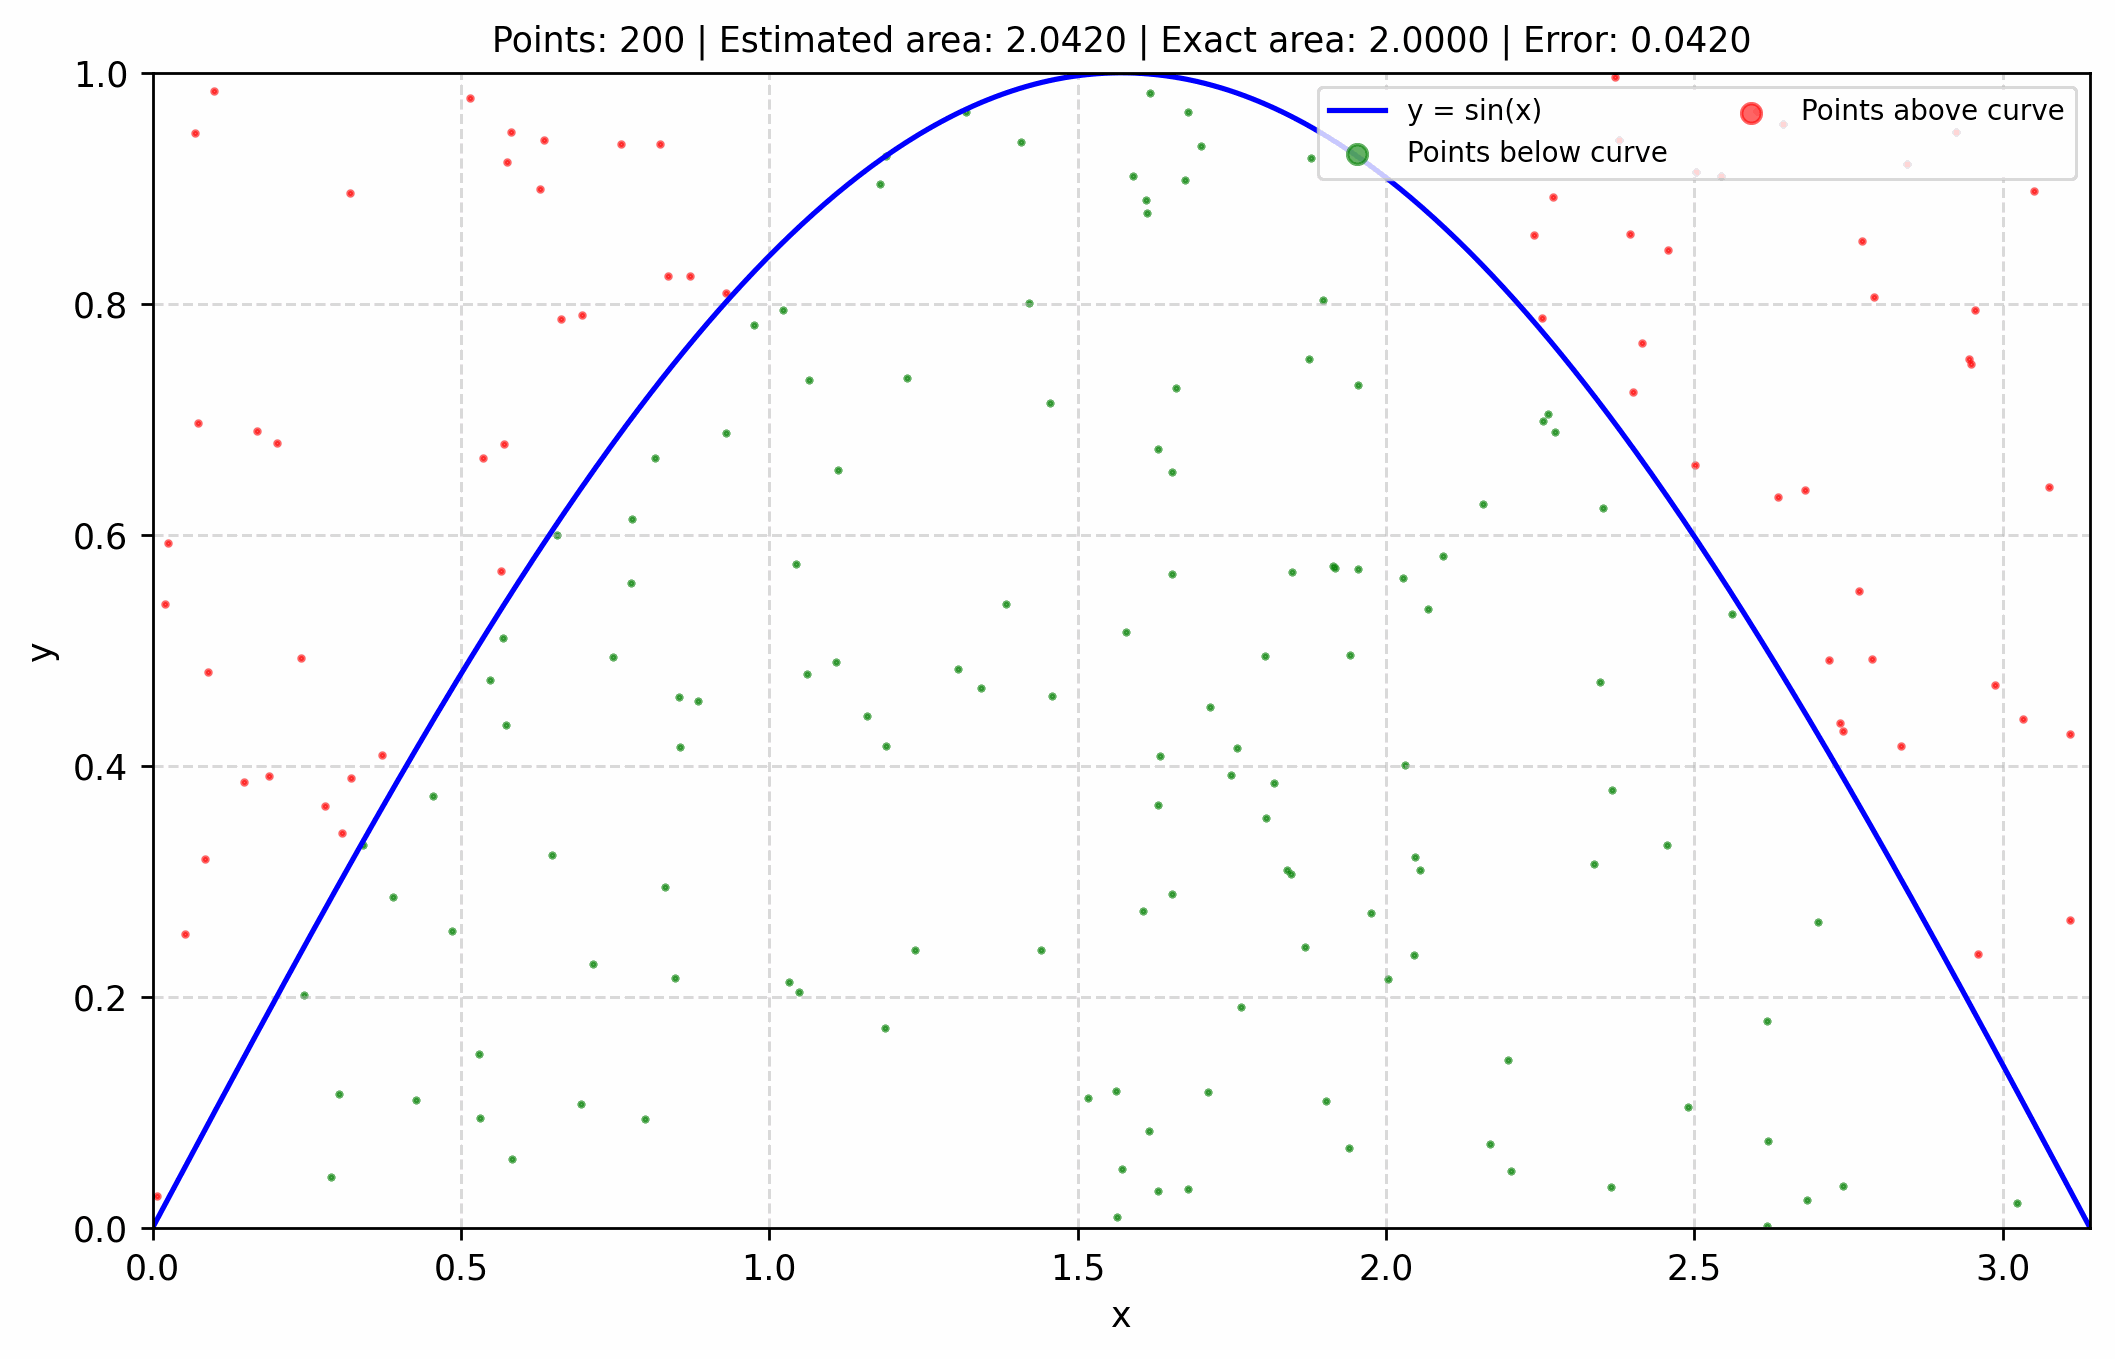

In [9]:
"""This script generates an animated Monte Carlo integration simulation in memory using CuPy and Matplotlib."""

import io
import math
import cupy as cp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as IPyImage

# Control Knobs
TOTAL_POINTS = 10000
FRAMES = 50
GIF_FPS = 12
FREE_MEMORY_INTERVAL = 8
DPI = 250
X_MIN = 0.0
X_MAX = math.pi
Y_MIN = 0.0
Y_MAX = 1.0

# Plotting Configuration
matplotlib.rcParams['figure.dpi'] = DPI
matplotlib.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
matplotlib.rcParams['font.weight'] = 'normal'

def run_simulation() -> None:
    """This script computes the Monte Carlo integration and compiles an in-memory GIF animation."""

    bounding_area = (X_MAX - X_MIN) * (Y_MAX - Y_MIN)
    exact_area = 2.0
    points_per_frame = TOTAL_POINTS // FRAMES

    x_gpu = cp.random.uniform(X_MIN, X_MAX, TOTAL_POINTS)
    y_gpu = cp.random.uniform(Y_MIN, Y_MAX, TOTAL_POINTS)

    y_curve_gpu = cp.sin(x_gpu)
    hits_gpu = y_gpu <= y_curve_gpu

    x_curve = np.linspace(X_MIN, X_MAX, 500)
    y_curve = np.sin(x_curve)

    image_frames = []
    fig, ax = plt.subplots(figsize=(10, 6))

    for i in range(FRAMES):
        current_index = (i + 1) * points_per_frame

        x_cpu = cp.asnumpy(x_gpu[:current_index])
        y_cpu = cp.asnumpy(y_gpu[:current_index])
        hits_cpu = cp.asnumpy(hits_gpu[:current_index])

        hits_count = np.sum(hits_cpu)
        estimated_area = bounding_area * (hits_count / current_index)
        error = abs(estimated_area - exact_area)

        x_hits = x_cpu[hits_cpu]
        y_hits = y_cpu[hits_cpu]
        x_misses = x_cpu[~hits_cpu]
        y_misses = y_cpu[~hits_cpu]

        ax.clear()
        ax.plot(x_curve, y_curve, color='blue', linewidth=1.5, label='y = sin(x)')
        ax.scatter(x_hits, y_hits, color='green', s=2, alpha=0.6, label='Points below curve')
        ax.scatter(x_misses, y_misses, color='red', s=2, alpha=0.6, label='Points above curve')

        title_text = (f"Points: {current_index} | "
                      f"Estimated area: {estimated_area:.4f} | "
                      f"Exact area: {exact_area:.4f} | "
                      f"Error: {error:.4f}")
        ax.set_title(title_text, fontsize=10)
        ax.set_xlim(X_MIN, X_MAX)
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right', fontsize=8, markerscale=4, ncol=2)

        buffer = io.BytesIO()
        fig.savefig(buffer, format='png', bbox_inches='tight')
        buffer.seek(0)
        image_frames.append(Image.open(buffer))

        if (i + 1) % FREE_MEMORY_INTERVAL == 0:
            cp.get_default_memory_pool().free_all_blocks()

    plt.close(fig)

    gif_buffer = io.BytesIO()
    image_frames[0].save(
        gif_buffer,
        format='GIF',
        append_images=image_frames[1:],
        save_all=True,
        duration=(1000 // GIF_FPS),
        loop=0
    )

    gif_buffer.seek(0)
    display(IPyImage(data=gif_buffer.getvalue(), format='gif'))

if __name__ == '__main__':
    run_simulation()